# SVM Classification Analysis for Heart Disease Prediction
**Machine Learning Assignment — Member 3**  
**Algorithm: Support Vector Machine (Binary Classification)**

---

In [2]:
# Core libraries for data handling
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Utilities for splitting and evaluating the model
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# Preprocessing and modeling tools
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

## Data Loading and Parsing
Load the Cleveland dataset from file and parse raw records into a structured table for analysis.

In [3]:
# Define the raw Cleveland dataset path (relative to project root)
data_path = "../Data_set/processed.cleveland.data"

# Read the whole raw file as text 
with open(data_path, "r", encoding="latin-1") as f:
    raw_text = f.read()


def parse_token(token):
    token = token.strip()
    if token in {"", "?"}:
        return None

    try:
        return float(token)
    except ValueError:
        return None


# Build records from comma-separated values line by line
records = []
for line in raw_text.splitlines():
    clean_line = line.replace("\x00", "").strip()
    if not clean_line:
        continue

    records.append([parse_token(token) for token in clean_line.split(",")])

parsed_count = len(records)
print("Parsed records:", parsed_count)
# Basic check to ensure rows were extracted
print("Number of patient records parsed:", parsed_count)
print("Example row length:", len(records[0]) if parsed_count > 0 else 0)

Parsed records: 303
Number of patient records parsed: 303
Example row length: 14


### DataFrame Construction and Feature Mapping
Convert parsed rows into a DataFrame, align columns with Cleveland feature definitions, and prepare a binary target variable.

In [4]:
# Convert parsed records into a DataFrame
raw_df = pd.DataFrame(records)

# Attribute positions from heart-disease.names (1-based -> converted to 0-based)
selected_indices = [2, 3, 8, 9, 11, 15, 18, 31, 37, 39, 40, 43, 50, 57]

# Human-readable column names for the selected attributes
selected_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

# If records are already the 14 selected columns (as in processed.cleveland.data), use them directly.
# Otherwise, select by positional indices from a wider raw table.
if raw_df.shape[1] == len(selected_columns):
    df = raw_df.copy()
    df.columns = selected_columns
else:
    df = raw_df.iloc[:, selected_indices].copy()
    df.columns = selected_columns

# Replace raw missing indicator -9 with NaN for proper imputation later
df.replace(-9, np.nan, inplace=True)

# Convert multiclass diagnosis into binary classification: 0 = no heart disease, 1 = heart disease
df["target"] = (df["num"] > 0).astype(int)

# Drop the original "num" column because "target" is now the prediction label
df.drop(columns=["num"], inplace=True)

# Show data snapshot and missing counts
print(df.head())
print("\nMissing values per column:\n", df.isnull().sum())
print("\nClass distribution:\n", df["target"].value_counts())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Class distribution:
 target
0    164
1    139
Name: count, dtype: int64


### Data Cleaning and Validation
Clean feature values, enforce valid domain categories, and standardize missing or invalid entries before modeling.

In [5]:
# Data cleaning: enforce numeric types and standardize invalid entries as missing values
feature_cols = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal"
]

df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")

# Domain rules from Cleveland dataset coding
binary_cols = ["sex", "fbs", "exang"]
valid_binary = {0, 1}
for col in binary_cols:
    df.loc[~df[col].isin(valid_binary), col] = np.nan

valid_categories = {
    "cp": {1, 2, 3, 4},
    "restecg": {0, 1, 2},
    "slope": {1, 2, 3},
    "thal": {3, 6, 7},
}
for col, valid_set in valid_categories.items():
    df.loc[~df[col].isin(valid_set), col] = np.nan

# Physiologically impossible negative values are treated as missing
for col in ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]:
    df.loc[df[col] < 0, col] = np.nan

# Ensure target is strictly binary and remove duplicate records
df = df[df["target"].isin([0, 1])].copy()
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print("Data cleaning completed.")
print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal :", rows_after)
print("Duplicates removed           :", rows_before - rows_after)
print("\nMissing values after cleaning:\n", df.isnull().sum())

Data cleaning completed.
Rows before duplicate removal: 303
Rows after duplicate removal : 303
Duplicates removed           : 0

Missing values after cleaning:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


## Model Training and Baseline Evaluation
Split the cleaned data, train a baseline SVM pipeline, and measure initial classification performance.

In [6]:
# Separate features (X) and label (y)
X = df.drop(columns=["target"])
y = df["target"]

# Split data to training set and Testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build a pipeline to Median imputation, Standardization for SVM & probability enabled for ROC-AUC
svm_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced", random_state=42))
])

# Train the pipeline on training data
svm_pipeline.fit(X_train, y_train)

print("Training completed.")

Training completed.


In [7]:
def evaluate_model(model, X_eval, y_eval, title):
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval)[:, 1]

    metrics = {
        "acc": accuracy_score(y_eval, pred),
        "prec": precision_score(y_eval, pred),
        "rec": recall_score(y_eval, pred),
        "f1": f1_score(y_eval, pred),
        "auc": roc_auc_score(y_eval, prob),
    }

    print(title)
    print(f"Accuracy : {metrics['acc']:.4f}")
    print(f"Precision: {metrics['prec']:.4f}")
    print(f"Recall   : {metrics['rec']:.4f}")
    print(f"F1-score : {metrics['f1']:.4f}")
    print(f"ROC-AUC  : {metrics['auc']:.4f}")

    # Print confusion matrix and full classification report
    print("\nConfusion Matrix:\n", confusion_matrix(y_eval, pred))
    print("\nClassification Report:\n", classification_report(y_eval, pred))

    return pred, prob, metrics


# Baseline model evaluation on test set
y_pred, y_prob, baseline_metrics = evaluate_model(
    svm_pipeline,
    X_test,
    y_test,
    "Baseline SVM Results",
)

acc = baseline_metrics["acc"]
prec = baseline_metrics["prec"]
rec = baseline_metrics["rec"]
f1 = baseline_metrics["f1"]
auc = baseline_metrics["auc"]

Baseline SVM Results
Accuracy : 0.8689
Precision: 0.8125
Recall   : 0.9286
F1-score : 0.8667
ROC-AUC  : 0.9437

Confusion Matrix:
 [[27  6]
 [ 2 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



## Hyperparameter Tuning
Use GridSearchCV with stratified cross-validation to find the best SVM configuration for ROC-AUC.

In [8]:
# Define parameter grid for SVM inside the pipeline
param_grid = {
    "svm__C": [0.1, 1, 10, 50],
    "svm__gamma": ["scale", 0.01, 0.1, 1],
    "svm__kernel": ["rbf", "linear"]
}

# Use stratified 5-fold CV for robust model selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Optimize for ROC-AUC because this is a medical classification problem
grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Fit grid search on training set only
grid_search.fit(X_train, y_train)

# Get the best model from CV
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV ROC-AUC: 0.8981537785885612


Tuned SVM Results
Accuracy : 0.8525
Precision: 0.8065
Recall   : 0.8929
F1-score : 0.8475
ROC-AUC  : 0.9372

Confusion Matrix:
 [[27  6]
 [ 3 25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61


Heart Disease Prediction - SVM Classification Summary Report
Best Parameters: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV ROC-AUC: 0.8982
Test Accuracy : 0.8525
Test Precision: 0.8065
Test Recall   : 0.8929
Test F1-score : 0.8475
Test ROC-AUC  : 0.9372

Sample predictions (first 10 rows):
      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
219  59.0  1.0  4.0     138.0  271.0  0.0      2.0    182.0    0.0      0.0   
271  66.0  1.0  4.0     160.0  2

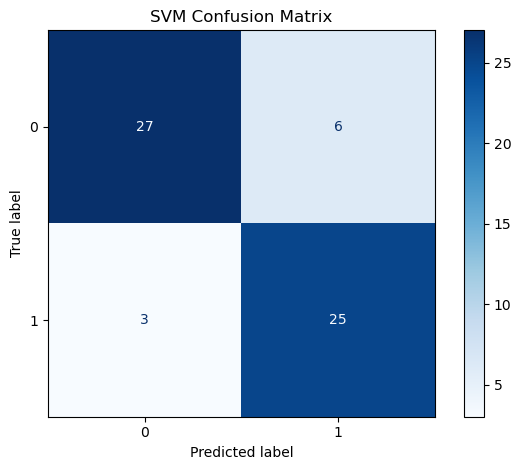

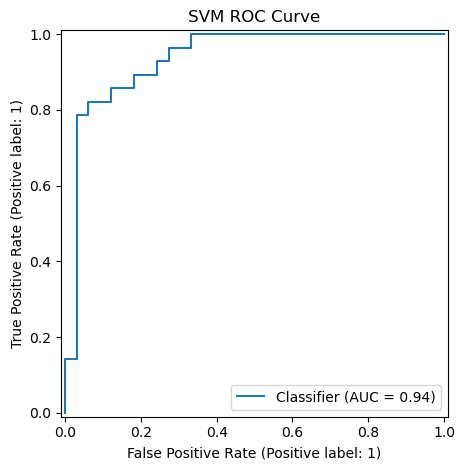

In [9]:
# Evaluate tuned model on test data
best_pred, best_prob, tuned_metrics = evaluate_model(
    best_model,
    X_test,
    y_test,
    "Tuned SVM Results",
)

best_acc = tuned_metrics["acc"]
best_prec = tuned_metrics["prec"]
best_rec = tuned_metrics["rec"]
best_f1 = tuned_metrics["f1"]
best_auc = tuned_metrics["auc"]

# Show consolidated final results immediately after model tuning
print("\nHeart Disease Prediction - SVM Classification Summary Report")
print("=" * 68)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Test Accuracy : {best_acc:.4f}")
print(f"Test Precision: {best_prec:.4f}")
print(f"Test Recall   : {best_rec:.4f}")
print(f"Test F1-score : {best_f1:.4f}")
print(f"Test ROC-AUC  : {best_auc:.4f}")

# Display prediction-level outputs
predictions_df = X_test.copy()
predictions_df["actual"] = y_test.values
predictions_df["predicted"] = best_pred
predictions_df["probability"] = best_prob

print("\nSample predictions (first 10 rows):")
print(predictions_df.head(10))

# Display confusion matrix values
cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(
    cm,
    index=["actual_0", "actual_1"],
    columns=["pred_0", "pred_1"],
)
print("\nConfusion Matrix Table:")
print(cm_df)

# Show confusion matrix figure inline
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp_cm.plot(cmap="Blues", values_format="d")
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

# Show ROC curve figure inline
RocCurveDisplay.from_predictions(y_test, best_prob)
plt.title("SVM ROC Curve")
plt.tight_layout()
plt.show()

## Patient-Level Prediction Example
Run inference for a sample patient and interpret the disease probability from the tuned model.

In [10]:
# Example patient row using the same feature order as training columns
sample_patient = pd.DataFrame([{
    "age": 26,
    "sex": 1,
    "cp": 1,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 140,
    "exang": 1,
    "oldpeak": 2.0,
    "slope": 2,
    "ca": 1,
    "thal": 7
}])

# Predict class and probability using tuned model
sample_pred = best_model.predict(sample_patient)[0]
sample_prob = best_model.predict_proba(sample_patient)[0, 1]

# Display patient-level prediction
print("Predicted class (0=no disease, 1=disease):", int(sample_pred))
print("Predicted disease probability:", round(float(sample_prob), 4))
print("Interpretation: This patient has a {:.2%} chance of having heart disease.".format(sample_prob))
print("Model Accuracy on Test Set: {:.2%}".format(best_acc))

Predicted class (0=no disease, 1=disease): 1
Predicted disease probability: 0.769
Interpretation: This patient has a 76.90% chance of having heart disease.
Model Accuracy on Test Set: 85.25%
